# Causal Attention

## Setup — importing PyTorch

- `torch` gives us tensors and automatic differentiation (autograd).
- `torch.nn` gives the neural-network building blocks we use below: `nn.Linear` (the trainable Q/K/V projections), `nn.Dropout`, and `nn.Module` (the base class for our layers).

In [1]:
import torch
import torch.nn as nn

## The input embeddings

Our toy sentence **"Today i am learning deepseek course"** — **6 tokens**, each already turned into a **3-dimensional** embedding vector `x^(i)`. The tensor shape is `(6, 3)` = *(tokens, features)*. These are the vectors self-attention will mix together.

In [2]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Today     (x^1)
    [0.55, 0.87, 0.66], #  i         (x^2)
    [0.57, 0.85, 0.64], # am         (x^3)
    [0.22, 0.58, 0.33], # learning   (x^4)
    [0.77, 0.25, 0.10], # deepseek   (x^5)
    [0.05, 0.80, 0.55] # course      (x^6)
    ]
)

## Recap — standard (bidirectional) self-attention

Three **trainable** projections turn each token into a *query*, *key* and *value*, then we compute scaled dot-product attention:

$$
\text{Attention}(Q,K,V)=\operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V
$$

where $Q=XW_Q,\;K=XW_K,\;V=XW_V$ and $d_k$ = `d_out`. `bias=False` drops the bias term (standard for Q/K/V). This version is **bidirectional** — every token can see every other token, including the future.

In [3]:
class SelfAttention(nn.Module):

    def __init__(self, d_in, d_out, qkv_bias=False):

        super().__init__()
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)

    def forward(self, X):
        keys = self.W_key(X)
        queries = self.W_query(X)
        values = self.W_value(X)

        atten_scores = queries @ keys.T
        atten_weight = torch.softmax(atten_scores / keys.shape[-1] ** 0.5, dim=1)

        context_vector = atten_weight @ values
        return context_vector

### Instantiate & run

`d_in = 3` matches the embedding size; `d_out = 6` is the width of each query/key/value. Passing `inputs` `(6, 3)` through the layer returns **6 context vectors** of shape `(6, 6)` — one enriched vector per token.

In [4]:
d_in = 3
d_out = 6

self_attention = SelfAttention(d_in, d_out)
print(self_attention(inputs))

tensor([[ 0.0851,  0.2521,  0.2615, -0.1101,  0.5864,  0.0852],
        [ 0.0917,  0.2515,  0.2645, -0.1102,  0.5837,  0.0784],
        [ 0.0916,  0.2515,  0.2644, -0.1102,  0.5838,  0.0785],
        [ 0.0884,  0.2519,  0.2630, -0.1105,  0.5855,  0.0807],
        [ 0.0860,  0.2518,  0.2617, -0.1103,  0.5858,  0.0831],
        [ 0.0903,  0.2519,  0.2640, -0.1105,  0.5850,  0.0792]],
       grad_fn=<MmBackward0>)


## Peeking inside — Q, K, V

To make the masking visible later, we recompute the intermediate tensors by hand. Each `nn.Linear` is just a matrix multiply $XW$:

$$
Q = XW_Q,\qquad K = XW_K,\qquad V = XW_V
$$

The next three cells print the **queries**, **keys** and **values** — each of shape `(6, 6)` (one row per token).

In [5]:
queries = self_attention.W_query(inputs)
print("Queries values are = ", queries)

Queries values are =  tensor([[ 0.5272, -0.3418, -0.1647, -0.3613,  0.4547, -0.1013],
        [ 0.3235, -0.7123,  0.4329, -0.2717,  0.3075,  0.1529],
        [ 0.3202, -0.7030,  0.4439, -0.2805,  0.3101,  0.1484],
        [ 0.1286, -0.4200,  0.2670, -0.0877,  0.1133,  0.1250],
        [ 0.1712, -0.3359,  0.5160, -0.3619,  0.2703,  0.0258],
        [ 0.1750, -0.5353,  0.1744, -0.0146,  0.1020,  0.1718]],
       grad_fn=<MmBackward0>)


In [6]:
keys = self_attention.W_key(inputs)
print("Keys Values = ", keys)

Keys Values =  tensor([[-0.1274, -0.1325, -0.1391, -0.1444, -0.2737, -0.0573],
        [-0.6565,  0.1884, -0.1979,  0.0100,  0.0869, -0.1676],
        [-0.6605,  0.1683, -0.1930,  0.0200,  0.0797, -0.1754],
        [-0.3808,  0.1970, -0.1160,  0.0010,  0.1189, -0.0737],
        [-0.5470, -0.2421, -0.0515,  0.1929, -0.0732, -0.2678],
        [-0.3641,  0.3943, -0.1697, -0.0948,  0.1883, -0.0043]],
       grad_fn=<MmBackward0>)


In [7]:
values = self_attention.W_value(inputs)
print("Values = ", values)

Values =  tensor([[ 0.4001,  0.3049,  0.4896, -0.1201,  0.6392, -0.0304],
        [ 0.0429,  0.3294,  0.3030, -0.1454,  0.7817,  0.1508],
        [ 0.0537,  0.3260,  0.3053, -0.1450,  0.7718,  0.1351],
        [-0.0675,  0.1679,  0.1056, -0.0732,  0.4175,  0.1445],
        [ 0.2326,  0.1744,  0.2623, -0.0980,  0.3773, -0.1859],
        [-0.1654,  0.2129,  0.0969, -0.0822,  0.5420,  0.2991]],
       grad_fn=<MmBackward0>)


## Attention scores — $QK^\top$

The dot product of **every query with every key** measures how strongly token *i* should attend to token *j*. The result is a `(6, 6)` matrix: **row = query token, column = key token**. Large value ⇒ high relevance.

In [8]:
atten_scores = queries @ keys.T
print("Attention Scores = ", atten_scores)

Attention Scores =  tensor([[-0.0655, -0.3251, -0.3272, -0.1878, -0.2730, -0.1785],
        [-0.0608, -0.4338, -0.4248, -0.2887, -0.1426, -0.3891],
        [-0.0623, -0.4312, -0.4224, -0.2863, -0.1444, -0.3847],
        [-0.0234, -0.2284, -0.2218, -0.1585, -0.0411, -0.2286],
        [-0.0723, -0.2622, -0.2594, -0.1613, -0.1354, -0.1973],
        [-0.0113, -0.2703, -0.2616, -0.1929, -0.0314, -0.2845]],
       grad_fn=<MmBackward0>)


## Scaled softmax → attention weights

Divide the scores by $\sqrt{d_k}$ (keeps gradients stable for large $d_k$), then apply `softmax` along each **row** so the weights become a probability distribution that sums to 1:

$$
\alpha = \operatorname{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)
$$

⚠️ Right now every token attends to **all** others — including future tokens. Everything below removes that ability.

In [9]:
atten_weight = torch.softmax(atten_scores / keys.shape[-1] ** 0.5, dim=1)
print("Attention Weight = ", atten_weight)

Attention Weight =  tensor([[0.1778, 0.1600, 0.1598, 0.1692, 0.1634, 0.1698],
        [0.1827, 0.1569, 0.1575, 0.1665, 0.1767, 0.1598],
        [0.1825, 0.1570, 0.1575, 0.1665, 0.1765, 0.1600],
        [0.1754, 0.1613, 0.1618, 0.1660, 0.1742, 0.1613],
        [0.1742, 0.1612, 0.1614, 0.1680, 0.1698, 0.1655],
        [0.1780, 0.1602, 0.1607, 0.1653, 0.1766, 0.1592]],
       grad_fn=<SoftmaxBackward0>)


# Implementing the Approch 1st -
Keep all the above diagonal values to zero in attention weights matrix

**In code:** `torch.tril(torch.ones(n, n))` builds a **lower-triangular** matrix of 1s (keep) and 0s (block). `context_length` = number of tokens = 6. A `1` at *(i, j)* means *"token i may attend to token j."*

In [10]:
context_length = atten_scores.shape[0]
mask_simple = torch.tril(torch.ones(context_length, context_length))
print(mask_simple)

tensor([[1., 0., 0., 0., 0., 0.],
        [1., 1., 0., 0., 0., 0.],
        [1., 1., 1., 0., 0., 0.],
        [1., 1., 1., 1., 0., 0.],
        [1., 1., 1., 1., 1., 0.],
        [1., 1., 1., 1., 1., 1.]])


Now, we can multiply this mask with the attention weights to zero out the values above the diagonal

In [11]:
masked_simple = atten_weight * mask_simple
print(masked_simple)

tensor([[0.1778, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1827, 0.1569, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.1825, 0.1570, 0.1575, 0.0000, 0.0000, 0.0000],
        [0.1754, 0.1613, 0.1618, 0.1660, 0.0000, 0.0000],
        [0.1742, 0.1612, 0.1614, 0.1680, 0.1698, 0.0000],
        [0.1780, 0.1602, 0.1607, 0.1653, 0.1766, 0.1592]],
       grad_fn=<MulBackward0>)


As we can see, the elements above the diagonal are successfully zeroed out.  </br></br>
The third step is to renormalize the attention weights to sum up to 1 again in each row. </br>
We can achieve this by deviding each element in each row by the sum in each row. 

In [12]:
row_sums = masked_simple.sum(dim=1, keepdim=True)
masked_simple_normalize = masked_simple / row_sums
print(masked_simple_normalize)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5380, 0.4620, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3672, 0.3158, 0.3170, 0.0000, 0.0000, 0.0000],
        [0.2640, 0.2428, 0.2434, 0.2498, 0.0000, 0.0000],
        [0.2087, 0.1932, 0.1934, 0.2013, 0.2034, 0.0000],
        [0.1780, 0.1602, 0.1607, 0.1653, 0.1766, 0.1592]],
       grad_fn=<DivBackward0>)


# Approach 2: We start with the Attention Scores

**Approach 2 — mask the scores, not the weights.** `torch.triu` returns the **upper** triangle — exactly the *future* positions we want to remove. Instead of zeroing weights *after* softmax (Approach 1), we will blank the raw scores *before* softmax, which is cleaner and needs no renormalization.

In [13]:
torch.triu(torch.ones(context_length, context_length))

tensor([[1., 1., 1., 1., 1., 1.],
        [0., 1., 1., 1., 1., 1.],
        [0., 0., 1., 1., 1., 1.],
        [0., 0., 0., 1., 1., 1.],
        [0., 0., 0., 0., 1., 1.],
        [0., 0., 0., 0., 0., 1.]])

### Fill the future with $-\infty$

`diagonal=1` keeps the main diagonal unmasked (a token may attend to itself), then `masked_fill` sets every future score to $-\infty$. Because $e^{-\infty}=0$, the next softmax assigns those positions exactly **0** weight — and the surviving weights already sum to 1, so **no renormalization is needed**.

In [14]:
mask = torch.triu(torch.ones(context_length, context_length), diagonal=1)
masked = atten_scores.masked_fill(mask.bool(), -torch.inf)
print(masked)

tensor([[-0.0655,    -inf,    -inf,    -inf,    -inf,    -inf],
        [-0.0608, -0.4338,    -inf,    -inf,    -inf,    -inf],
        [-0.0623, -0.4312, -0.4224,    -inf,    -inf,    -inf],
        [-0.0234, -0.2284, -0.2218, -0.1585,    -inf,    -inf],
        [-0.0723, -0.2622, -0.2594, -0.1613, -0.1354,    -inf],
        [-0.0113, -0.2703, -0.2616, -0.1929, -0.0314, -0.2845]],
       grad_fn=<MaskedFillBackward0>)


Now, all we need to do is apply the softmax function to these masked results, and we are done

In [15]:
atten_weight = torch.softmax(masked / keys.shape[-1] ** 0.5, dim=1)
print(atten_weight)

tensor([[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.5380, 0.4620, 0.0000, 0.0000, 0.0000, 0.0000],
        [0.3672, 0.3158, 0.3170, 0.0000, 0.0000, 0.0000],
        [0.2640, 0.2428, 0.2434, 0.2498, 0.0000, 0.0000],
        [0.2087, 0.1932, 0.1934, 0.2013, 0.2034, 0.0000],
        [0.1780, 0.1602, 0.1607, 0.1653, 0.1766, 0.1592]],
       grad_fn=<SoftmaxBackward0>)


## 🖼️ Visualizing the causal attention weights

The heatmap below shows the causal weights from Approach 2: each row is a query token, each column a key token. The `×` (masked) cells are the future positions that received **zero** weight, so every token only attends to itself and earlier tokens.

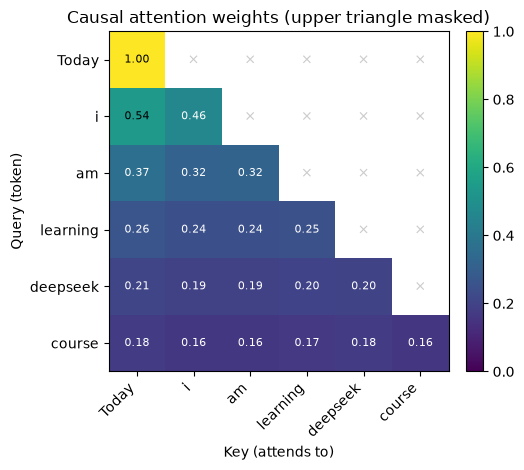

In [16]:
import matplotlib.pyplot as plt
import numpy as np

tokens = ["Today", "i", "am", "learning", "deepseek", "course"]
W = atten_weight.detach().numpy()          # causal weights from Approach 2

fig, ax = plt.subplots(figsize=(5.6, 4.8))
im = ax.imshow(np.where(W == 0, np.nan, W), cmap="viridis", vmin=0, vmax=1)
ax.set_xticks(range(6)); ax.set_yticks(range(6))
ax.set_xticklabels(tokens, rotation=45, ha="right")
ax.set_yticklabels(tokens)
ax.set_xlabel("Key (attends to)"); ax.set_ylabel("Query (token)")
ax.set_title("Causal attention weights (upper triangle masked)")
for i in range(6):
    for j in range(6):
        if W[i, j] == 0:
            ax.text(j, i, "×", ha="center", va="center", color="#cccccc")
        else:
            ax.text(j, i, f"{W[i, j]:.2f}", ha="center", va="center",
                    color="white" if W[i, j] < 0.5 else "black", fontsize=8)
fig.colorbar(im, fraction=0.046, pad=0.04)
fig.tight_layout()
plt.show()

<h3> MASKING ADDITIONAL ATTENTION WEIGHTS WITH DROPOUT </h3>
<p>Dropout is a deep learning technique where randomly selected hidden layer units are ignored during training . This prevents overfitting and improves generalization performance.</p> </br>
Droput usally do the work from lazy neurons.</br></br>
In the following code example, we use a dropout rate of 50%, which means making out of half of the attention weights. </br>
When we train the GPT model in later chapters, we will use a lower droput rate, suct as 0.1 or 0.2. </br> </br>

In the following code, we apply PyTorch's dropout implementation firdt to 6x6 tensor consisting of ones for illustration purposes:

In [17]:
example = torch.ones(6,6)
print(example)

tensor([[1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.],
        [1., 1., 1., 1., 1., 1.]])


**Dropout on a matrix of ones.** With rate `0.5`, roughly half the entries are randomly set to `0`, and every survivor is scaled by $\frac{1}{1-0.5}=2$ — that is why the kept entries print as `2.` instead of `1.`. (Seed `123` makes the random pattern reproducible.)

In [18]:
torch.manual_seed(123)
dropout = torch.nn.Dropout(0.5)
example = torch.ones(6,6)
print(dropout(example))

tensor([[2., 2., 0., 2., 2., 0.],
        [0., 0., 0., 2., 0., 2.],
        [2., 2., 2., 2., 0., 2.],
        [0., 2., 2., 0., 0., 2.],
        [0., 2., 0., 2., 0., 2.],
        [0., 2., 2., 2., 2., 0.]])


When applying dropout to an attention weight matrix with a rate of 50%, half of the elements in the matrix are randomly set to zero. </br>
To compensate for the reduction in active elements, the values of the remaining in the matrix are scaled up by a factor of 1/0.5=2.</br>
This scaling is crucial to maintain the overall balance of the attention weights, ensuring that the average influence of the attention mechanism remains consistent during both the training and inference phases.

**The dropout scaling, formally.** With dropout probability $p$, each weight is either dropped (set to 0) or kept and scaled by $\frac{1}{1-p}$:

$$
\tilde{\alpha}_{ij}=
\begin{cases}
\dfrac{\alpha_{ij}}{1-p} & \text{with prob. } (1-p) \;\;[\text{kept}]\\[2mm]
0 & \text{with prob. } p \;\;[\text{dropped}]
\end{cases}
$$

At $p = 0.5$ the surviving weights are multiplied by $\frac{1}{1-0.5}=2$ — that is why the tensor above shows `2.` instead of `1.`. The scaling keeps the **expected** value of each weight unchanged, so the model behaves consistently between **training** (dropout on) and **inference** (dropout off).

# Implementing a compact causal attention class

### Building a batch

Real training feeds **many sequences at once**, so our attention layer must handle a 3-D input. `torch.stack` duplicates the `(6, 3)` sequence twice → shape `(2, 6, 3)` = **(batch, tokens, features)**.

In [19]:
inputs = torch.tensor(
    [[0.43, 0.15, 0.89], # Today     (x^1)
    [0.55, 0.87, 0.66], #  i         (x^2)
    [0.57, 0.85, 0.64], # am         (x^3)
    [0.22, 0.58, 0.33], # learning   (x^4)
    [0.77, 0.25, 0.10], # deepseek   (x^5)
    [0.05, 0.80, 0.55] # course      (x^6)
    ]
)
batch = torch.stack((inputs, inputs), dim=0)
print(batch.shape)


torch.Size([2, 6, 3])


 number if batches = 2 </br>
 number of tokens = 6 </br>
 token dimesnion = 3

In [20]:
class CausalAttention(nn.Module):

    def __init__(self, d_in, d_out, context_length, dropout, qkv_bias=False):

        super().__init__()
        self.d_out = d_out
        self.W_query = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_value = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, X):
        b, num_tokens, d_in = X.shape
        keys = self.W_key(X)
        queries = self.W_query(X)
        values = self.W_value(X)

        atten_scores = queries @ keys.transpose(1, 2)
        atten_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens],
            -torch.inf
        )

        atten_weights = torch.softmax(
            atten_scores / keys.shape[-1] ** 0.5, dim=-1
        )
        atten_weights = self.dropout(atten_weights)

        context_vector = atten_weights @ values
        return context_vector

### What's new in this compact class?

It rolls the whole pipeline — projections → causal mask → dropout → context — into **one reusable module** that now works on **batches** of sequences.

| Feature | Why it matters |
|--------|----------------|
| `X.shape → (b, num_tokens, d_in)` | handles a **batch** of sequences, not a single one |
| `keys.transpose(1, 2)` | transposes only the last two dims; plain `.T` would wrongly flip the batch dim |
| `register_buffer('mask', …)` | the causal mask moves with the model (`.to(device)`) but is **not** a trainable parameter |
| `masked_fill_(…, -torch.inf)` | the efficient $-\infty$ trick from Approach 2 (the trailing `_` = in-place) |
| `[:num_tokens, :num_tokens]` | slices the mask so sequences shorter than `context_length` still work |
| `self.dropout(atten_weights)` | regularizes the attention weights during training |
| `dim=-1` | softmax over the **key** axis (last dim) — batch-safe |

**Shape walkthrough** for a batch of shape `(2, 6, 3)` with `d_out = 2`:

$$
\underbrace{X}_{(2,6,3)} \xrightarrow{W_Q,W_K,W_V} \underbrace{Q,K,V}_{(2,6,2)} \xrightarrow{QK^\top} \underbrace{\text{scores}}_{(2,6,6)} \xrightarrow{\text{mask}+\text{softmax}+\text{dropout}} \underbrace{\alpha}_{(2,6,6)} \xrightarrow{\alpha V} \underbrace{Z}_{(2,6,2)}
$$

In [21]:
# Run the compact class on the batch of 2 sequences
torch.manual_seed(123)
context_length = batch.shape[1]   # 6 tokens
d_in, d_out = 3, 2

ca = CausalAttention(d_in, d_out, context_length, dropout=0.0)
context_vectors = ca(batch)

print(context_vectors)
print("\ncontext_vectors.shape =", context_vectors.shape)   # -> (2, 6, 2)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)

context_vectors.shape = torch.Size([2, 6, 2])


## Quick sanity checks

The next few cells just confirm the hyper-parameters (`d_out = 2`, `d_in = 3`) and re-run the layer to verify the output shape is `(2, 6, 2)` = *(batch, tokens, d_out)*.

In [22]:
print(d_out)

2


In [23]:
print(d_in)

3


In [24]:
torch.manual_seed(123)
context_length = batch.shape[1]
casual_attention = CausalAttention(d_in, d_out, context_length, 0.0)
context_vector = casual_attention(batch)
print("context_vectors.shape ", context_vector.shape)

context_vectors.shape  torch.Size([2, 6, 2])


In [25]:
print(context_vector)

tensor([[[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]],

        [[-0.4519,  0.2216],
         [-0.5874,  0.0058],
         [-0.6300, -0.0632],
         [-0.5675, -0.0843],
         [-0.5526, -0.0981],
         [-0.5299, -0.1081]]], grad_fn=<UnsafeViewBackward0>)


## Watching dropout act on the attention weights

This final version prints the **causal attention weights before and after dropout** (rate `0.5`), so you can literally see ~half of them zeroed and the rest doubled.

> 🐛 **Bug fixed here:** the last line originally used `atten_weight * values` — an *element-wise* product of a `(2, 6, 6)` tensor with a `(2, 6, 2)` tensor, which raises `RuntimeError: size of tensor a (6) must match tensor b (2)`. The context vector is a **matrix multiply**: `atten_weight @ values` → `(2, 6, 6) @ (2, 6, 2) = (2, 6, 2)`.

In [26]:
import torch
import torch.nn as nn
class CausalAttention(nn.Module):
    def __init__(self,d_in, d_out, context_length, dropout, qkv_bias=False):
        super().__init__()
        self.d_out = d_out
        self.W_key = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_queries = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.W_values = nn.Linear(d_in, d_out, bias=qkv_bias)
        self.dropout = nn.Dropout(dropout)
        self.register_buffer('mask', torch.triu(torch.ones(context_length, context_length), diagonal=1))

    def forward(self, x):
        b, num_tokens, d_in = x.shape
        keys = self.W_key(x)
        queries = self.W_queries(x)
        values = self.W_values(x)

        atten_scores = queries @ keys.transpose(1,2)
        atten_scores.masked_fill_(
            self.mask.bool()[:num_tokens, :num_tokens], -torch.inf
        )

        atten_weight = torch.softmax(atten_scores / keys.shape[-1] ** 0.5, dim=-1)

        print("Attention Weights Before Dropout:\n", atten_weight)

        atten_weight = self.dropout(atten_weight)
        print("Attention Weights After Dropout:\n", atten_weight)

        context_vector = atten_weight @ values
        return context_vector
    
torch.manual_seed(123)
context_length = batch.shape[1]
casual_attention = CausalAttention(d_in, d_out, context_length, 0.5)
context_vector = casual_attention(batch)
print("context_vectors.shape ", context_vector.shape)


Attention Weights Before Dropout:
 tensor([[[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5155, 0.4845, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3475, 0.3262, 0.3262, 0.0000, 0.0000, 0.0000],
         [0.2571, 0.2523, 0.2522, 0.2384, 0.0000, 0.0000],
         [0.2145, 0.2004, 0.2005, 0.1879, 0.1967, 0.0000],
         [0.1728, 0.1711, 0.1710, 0.1599, 0.1638, 0.1614]],

        [[1.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.5155, 0.4845, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.3475, 0.3262, 0.3262, 0.0000, 0.0000, 0.0000],
         [0.2571, 0.2523, 0.2522, 0.2384, 0.0000, 0.0000],
         [0.2145, 0.2004, 0.2005, 0.1879, 0.1967, 0.0000],
         [0.1728, 0.1711, 0.1710, 0.1599, 0.1638, 0.1614]]],
       grad_fn=<SoftmaxBackward0>)
Attention Weights After Dropout:
 tensor([[[2.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [1.0310, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.6525, 0.0000, 0.0000, 0.0000],
       